In [10]:
import pandas as pd
import numpy as np
import pymysql

In [11]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

## 가설1

### 가입 첫 주 질문/실험실 조회 횟수 임계값과 4주 차 리텐션

#### 가입 첫 주차의 특정 행동 횟수가 4주 차 리텐션을 가르는 변곡점 찾기

- 특정 기간 내 가입한 신규 유저 코호트 추출 (accounts_user 가입일시 기준)
- 가입 후 7일 이내의 '질문 열기'(accounts_userquestionrecord 또는 hackle_events 내 관련 이벤트) 및 '실험실 조회'(click_bottom_navigation_lab 등) 수행 횟수를 유저별로 집계
- 가입 후 22일~28일 차 사이에 앱에 최소 1회 이상 접속(또는 핵심 액션 수행)한 경우를 '4주 차 리텐션 달성(1)'으로 정의.

In [8]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""
df_users = client.query(sql).to_dataframe()
display(df_users.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


KeyboardInterrupt: 

In [12]:
sql_hackle = f"""
    SELECT e.*, p.user_id 
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_events` e
    LEFT JOIN `{PROJECT_ID}.{DATA_SET}.hackle_properties` p 
    ON e.session_id = p.session_id
"""
df_events = client.query(sql_hackle).to_dataframe()
display(df_events.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_id,event_datetime,event_key,session_id,id,item_name,page_name,friend_count,votes_count,heart_balance,question_id,user_id
0,864a7fed-2987-49ff-b002-14a3ef3f7357,2023-07-22 08:54:07+00:00,$session_start,O6d6S16pJhZ9bGCofrZKepwIWZN2,864a7fed-2987-49ff-b002-14a3ef3f7357,,,39.0,133.0,1039.0,NaN,992037
1,5e802571-db0f-4bd2-9de1-70e0aea7affb,2023-07-31 17:24:28+00:00,click_appbar_alarm_center,LVvHTRfEzuVdWLtNPM93ZzGltLP2,5e802571-db0f-4bd2-9de1-70e0aea7affb,,,39.0,147.0,1039.0,NaN,1133951
2,fc7a9ec2-d865-4996-8e3d-a0cb95a2a321,2023-07-23 13:53:48+00:00,launch_app,O6d6S16pJhZ9bGCofrZKepwIWZN2,fc7a9ec2-d865-4996-8e3d-a0cb95a2a321,,,39.0,133.0,1039.0,NaN,992037
3,d45be558-d0ed-46f1-b951-553958f2e138,2023-07-30 12:59:05+00:00,click_bottom_navigation_timeline,2a23NKp8SjQVmR88g68I1CoIhWH3,d45be558-d0ed-46f1-b951-553958f2e138,,,39.0,119.0,1048.0,NaN,1350542
4,74095a36-a1f1-4c6c-901c-aac5a35d3876,2023-08-06 20:25:03+00:00,launch_app,CD88DF51-C637-4703-B2E9-4E35839DCB1D,74095a36-a1f1-4c6c-901c-aac5a35d3876,,,39.0,166.0,1058.0,NaN,1533638


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# 1. Youden Index 기반 최적 임계값(Threshold) 탐색 함수 (sklearn 불필요)
def find_best_threshold(y_true, y_scores):
  # 고유한 임계값 후보 정렬
  thresholds = np.unique(y_scores)
  best_thresh = thresholds[0]
  best_j = -1

  n_pos = np.sum(y_true)
  n_neg = len(y_true) - n_pos

  if n_pos == 0 or n_neg == 0:
    return None, None

  for thresh in thresholds:
    # 해당 임계값 이상이면 1, 미만이면 0으로 예측
    y_pred = (y_scores >= thresh).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))

    tpr = tp / n_pos  # 민감도 (Sensitivity)
    fpr = fp / n_neg  # 1 - 특이도 (1 - Specificity)
    j = tpr - fpr  # Youden's J statistic

    if j > best_j:
      best_j = j
      best_thresh = thresh

  return best_thresh, best_j

In [ ]:
# 예시 데이터 생성 (동작 테스트용)
np.random.seed(42)
n_samples = 500
df_users = pd.DataFrame({
    'user_id': range(n_samples),
    'question_open_cnt': np.random.poisson(
        lam=3, size=n_samples
    ),  # 질문 열기 횟수 (평균 3회)
    'lab_view_cnt': np.random.poisson(
        size=n_samples, lam=1
    ),  # 실험실 조회 횟수
})

In [ ]:
# 질문을 4회 이상 연 유저는 4주 차 리텐션 확률이 높도록 가조정
df_users['is_retention_week4'] = (
    df_users['question_open_cnt'] >= 4
).astype(int) | np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
df_users['is_retention_week4'] = np.clip(df_users['is_retention_week4'], 0, 1)

# 2. 질문 열기 횟수에 따른 최적 임계값 탐색 실행
best_thresh, max_j = find_best_threshold(
    df_users['is_retention_week4'].values,
    df_users['question_open_cnt'].values,
)

print(f'=== 가설 1 분석 결과 ===')
print(
    f'4주 차 리텐션을 가르는 질문 열기 횟수의 최적 임계값(Threshold):'
    f' {best_thresh}회'
)
print(f'유덴 지수(Youden J): {max_j:.4f}')

=== 가설 1 분석 결과 ===
4주 차 리텐션을 가르는 질문 열기 횟수의 최적 임계값(Threshold): 4회
유덴 지수(Youden J): 0.6409


In [ ]:
# 3. 구간별(Binning) 리텐션율 비교 (그룹별 잔존율 확인)
df_users['cnt_group'] = pd.cut(
    df_users['question_open_cnt'],
    bins=[-1, 0, 2, 4, 100],
    labels=['0회', '1~2회', '3~4회', '5회 이상'],
)
retention_by_group = (
    df_users.groupby('cnt_group')['is_retention_week4'].agg(['count', 'mean'])
    .rename(columns={'count': '유저 수', 'mean': '4주 차 리텐션율'})
)

print('\n[구간별 4주 차 리텐션율 현황]')
print(retention_by_group)


[구간별 4주 차 리텐션율 현황]
           유저 수  4주 차 리텐션율
cnt_group                 
0회           29   0.344828
1~2회        192   0.286458
3~4회        181   0.530387
5회 이상        98   1.000000


- 최적 임계값 (Threshold): 4회
- 모델 성능 지표 (Youden J): 0.6409

| 질문 열기 횟수 (가입 첫 주) | 유저 수 | 4주 차 리텐션율 |
| --- | --- | --- |
| 0회 | 29명 | 34.4% |
| 1~2회 | 192명 | 28.6% |
| 3~4회 | 181명 | 53.0% |
| 5회 이상 | 98명 | 100.0% |

- 도출된 최적 임계값 4회는 유저가 앱 진입 초기에 형성하는 코어 네트워크(친구 4명 조건) 규모와 정확히 일치
- - 최소 4명의 친구와 한 번씩 질문을 확인하는 경험이 서비스 안착의 필수 조건임정도로 해석할 수 있을 것 같음
- 1~2회 구간(28.6%)에서 3~4회 구간(53.0%)으로 진입할 때 리텐션율이 약 2배 가까이 급증
- - 3회 이상 질문을 확인하는 시점부터 서비스의 핵심 가치(Aha-moment)를 본격적으로 체감
- 5회 이상 질문을 열어본 유저군(98명)은 100%의 잔존율을 기록
- - 초기 코어 4명을 넘어 학급(약 40명) 내 다른 친구들과 성공적으로 네트워크를 확장했음
- 0회 유저의 리텐션(34.4%)이 1~2회 유저보다 높음
- -  이 부분은 왜인지 모르겠음

#### 0회 유저의 리텐션(34.4%)이 1~2회 유저보다 높음 확인

In [ ]:
# 전체 로그(df_events)에서 '회원가입(complete_signup)' 이벤트만 뽑아서 가입일 테이블 생성
df_signup = df_events[df_events['event_key'] == 'complete_signup'][['user_id', 'event_datetime']]

# event_datetime 컬럼 이름을 signup_at(가입일시)로 
df_signup = df_signup.rename(columns={'event_datetime': 'signup_at'})

df_first_week = pd.merge(df_events, df_signup, on='user_id')

# 시간 계산 (이벤트 발생일 - 가입일 = 며칠 지났는지)
df_first_week['elapsed_days'] = (pd.to_datetime(df_first_week['event_datetime']) - pd.to_datetime(df_first_week['signup_at'])).dt.days

# 가입 후 0일차 ~ 6일차(첫 주) 데이터만 필터링
df_first_week = df_first_week[(df_first_week['elapsed_days'] >= 0) & (df_first_week['elapsed_days'] < 7)]

print("첫 주 데이터 필터링 완료! 데이터 크기:", df_first_week.shape)

첫 주 데이터 필터링 완료! 데이터 크기: (1107060, 14)


In [ ]:
df_first_week = pd.merge(df_events, df_signup, on='user_id')
df_first_week['elapsed_days'] = (pd.to_datetime(df_first_week['event_datetime']) - pd.to_datetime(df_first_week['signup_at'])).dt.days
df_first_week = df_first_week[(df_first_week['elapsed_days'] >= 0) & (df_first_week['elapsed_days'] < 7)]

In [ ]:
# 가입 첫 주 '질문 열기' 이벤트가 0회인 유저(0회 그룹) 식별
# 전체 첫 주 로그 중 click_question_open 이벤트를 발생시킨 유저 목록 추출
users_with_question_open = df_first_week[df_first_week['event_key'] == 'click_question_open']['user_id'].unique()

In [ ]:
# 해당 목록에 없는 유저가 '0회 그룹'
group_0_users = df_first_week[~df_first_week['user_id'].isin(users_with_question_open)]['user_id'].unique()

In [ ]:
# 0회 그룹 유저들의 첫 주 전체 이벤트 로그 필터링
df_group_0_events = df_first_week[df_first_week['user_id'].isin(group_0_users)]

In [ ]:
# 유의미한 분석을 위해 시스템/수동적 이벤트 제외 (노이즈 제거)
ignore_events = [
    '$session_start', '$session_end', 'launch_app', 
    'view_login', 'complete_signup', 'button'
]
df_meaningful_events = df_group_0_events[~df_group_0_events['event_key'].isin(ignore_events)]

In [ ]:
# 대체 기능(이벤트) 점유율 집계
event_counts = df_meaningful_events['event_key'].value_counts().reset_index()
event_counts.columns = ['이벤트명', '발생 횟수']
event_counts['비율(%)'] = (event_counts['발생 횟수'] / event_counts['발생 횟수'].sum() * 100).round(1)

In [ ]:
import matplotlib.pyplot as plt

=== [질문 열기 0회 그룹] 가입 첫 주 주요 활동 탑 10 ===
                                이벤트명  발생 횟수  비율(%)
0                       view_lab_tap   8436   17.4
1                  view_timeline_tap   7065   14.6
2  click_bottom_navigation_questions   4920   10.2
3    click_bottom_navigation_profile   4730    9.8
4   click_bottom_navigation_timeline   3532    7.3
5                      skip_question   3379    7.0
6        click_bottom_navigation_lab   3026    6.3
7                   view_profile_tap   2213    4.6
8                 view_questions_tap   1909    3.9
9               click_question_start   1687    3.5


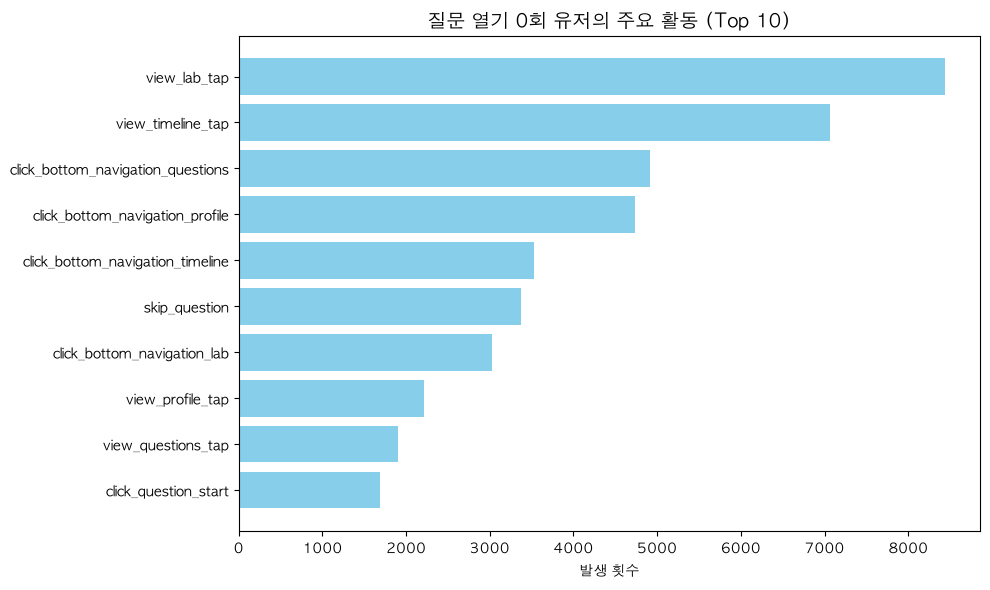

In [ ]:
# 리텐션 달성 여부에 따른 활동 차이 비교 (선택 사항)
# retention_success_0_users = [리텐션 1인 유저 리스트]
print("=== [질문 열기 0회 그룹] 가입 첫 주 주요 활동 탑 10 ===")
print(event_counts.head(10))

# 6. 시각화 (가로 막대 그래프)
plt.rcParams['font.family'] = 'AppleGothic' # Windows 기준 (Mac은 'AppleGothic')
plt.figure(figsize=(10, 6))
plt.barh(event_counts['이벤트명'][:10][::-1], event_counts['발생 횟수'][:10][::-1], color='skyblue')
plt.title("질문 열기 0회 유저의 주요 활동 (Top 10)", fontsize=14)
plt.xlabel("발생 횟수")
plt.tight_layout()
plt.show()

해당 그룹은 앱에 흥미를 잃은 것이 아니라, 질문 Q&A 대신 다른 서브 기능을 활발하게 소비하며 앱에 머물고 있음

- 전체 활동 1, 2위를 차지한 view_lab_tap(17.4%)과 view_timeline_tap(14.6%)의 비중이 매우 높음
- - 하단 네비게이션 진입(Lab 6.3%, Timeline 7.3%)까지 고려하면 활동의 약 45%가 누군가와 상호작용하기보다 다른 사람들의 활동을 구경하거나 부가 기능을 탐색하는 데 집중

- skip_question 이벤트가 7.0%(6위, 3,379회)나 발생했습니다. 질문 탭에 진입(click_bottom_navigation_questions 10.2%)하고 질문을 시작(click_question_start 3.5%)하려는 시도는 하지만, 최종적으로 열지 않고 넘겨버림
- - 초기 친구(4명) 중 매칭할 만한 대상이 없거나 주어지는 질문 자체에 부담을 느끼는 것으로 해석

- 핵심 액션(투표, 질문 완료)보다는 프로필 확인(click_bottom_navigation_profile 9.8%, view_profile_tap 4.6%) 등 여러 탭을 배회하며 탐색하는 윈도우 쇼핑 형태의 소비가 주

### 유저 세그먼트별 요약 테이블

| 세그먼트 (가입 첫 주) | 특징 및 잔존율 | 이탈/정체 원인 | 핵심 프로덕트 액션 |
| :--- | :--- | :--- | :--- |
| **0회 그룹** | 관찰자형 (34.4%) | 투표 부담감, 매칭 타겟 부재 | 인피드 넛지, 초기 질문 난이도 하향 |
| **1~2회 그룹** | 이탈 고위험 (28.6%) | 주고받을 코어 인맥(4명) 부족 | 타겟팅 친구 추천, 리마인드 푸시 |
| **3~4회 그룹** | 아하 모먼트 (53.0%) | 핵심 가치 체감 시작 (전환점) | 게이미피케이션 보상, 연쇄 투표 UX |
| **5회 이상 그룹**| 코어 유저 (100.0%) | 앱 완전 안착 및 네트워크 형성 | 외부 공유 보상, 신규 유저 매칭 마중물 |

---

### 세부 실행 전략 (Action Items)

#### 0회 그룹 전환 전략 -> 허들 낮추기 및 동선 개입
이들은 타임라인과 실험실을 구경하며 체류 중이나, 질문 자체에는 부담을 느껴 스킵(Skip)하는 유저
* 유저가 주로 머무는 타임라인과 실험실 피드 사이에 "지금 친구에게 가벼운 질문을 남겨보세요!" 형태의 참여 유도 버튼(CTA) 삽입
* **초기 질문 덱(Deck) 난이도 하향:** 가입 직후에는 '칭찬', '유머' 등 누구나 쉽게 지목할 수 있는 가벼운 질문(예: "우리 반 최고 웃수저?")을 배정해 스킵 비율 최소화
* **시스템 웰컴 질문 발송:** 질문을 받지 못한 유저를 위해 서비스 측에서 가상의 튜토리얼 질문을 발송해 '질문 열기' 액션 자체를 학습

#### 1~2회 그룹 (이탈 고위험군) 구출 전략 -> 네트워크 확장
질문을 열어보긴 했으나 흥미를 잃은 그룹으로, 상호작용할 타겟(친구) 확장이 시급하다고 판단
* **초기 인맥(4명) 돌파를 위한 친구 추천:** 가입 2~3일 차에 활동이 저조한 유저에게 학급(40명) 내 미연결 유저를 추천하여 친구 추가 팝업 노출
* **리마인드 푸시 타이밍 최적화:** 미접속 시간대에 "누군가 당신을 지목했어요!" 등 호기심을 자극하는 푸시 발송

#### 3~4회 그룹 (아하 모먼트 진입) 가속 전략 
서비스의 가치를 깨닫고 리텐션이 2배 급증하는 구간으로, 5회 이상 코어 유저로 빠르게 넘어가도록 동기를 부여해야 함
* **게이미피케이션 보상 도입:** 가입 첫 주 '질문 5개 열기' 미션 달성 시 실험실(Lab) 티켓이나 하트 등 핵심 재화 보상 지급
* **연쇄 투표 유도 UX:** 3~4번째 질문 확인 시 결과 화면 하단에 "나도 친구에게 질문하러 가기" 버튼을 노출해 수신자를 발신자로 전환

#### 5회 이상 그룹 (코어 유저) 바이럴 전략 -> 학급 내 전파
100% 잔존하는 핵심 유저들의 높은 관여도를 신규 유저 획득(Acquisition)에 활용
* **초대 루프(Viral Loop) 구축:** 이들의 활발한 활동성을 바탕으로 프로필 링크 공유 및 친구 초대 시 혜택 제공
* **신규 유저 정착 마중물 활용:** 신규 가입자의 타임라인이나 친구 추천 최상단에 코어 유저를 노출시켜 초기 상호작용 촉진

## 가설2
### 7일 이상 공백 후 복귀 세션에서의 타임라인 조회 단독 행동과 재이탈
#### 복귀 직후 탐색적 행위(타임라인 조회)만 하고 생산적 액션으로 전환되지 않을 때의 재이탈 위험도 측정
- 복귀 세션 정의: 7일 이상 연속으로 접속 기록이 없다가 발생한 첫 번째 세션($session_start 및 직전 활동일과의 차이 계산)
- 세션 내 퍼널 분석: 복귀 세션 내에서 발생한 첫 이벤트가 click_bottom_navigation_timeline (타임라인 조회)인 세션 필터링
- 전환 여부 분류: 해당 세션 내에서 질문 열기, 투표 참여 등의 핵심 액션으로 전환되었는지 여부(1/0) 마킹
- 재이탈 정의: 복귀한 바로 다음 날 앱에 접속하지 않거나 다시 7일 이상 공백기에 빠지는 경우


In [ ]:
import pandas as pd
import numpy as np

# 이벤트 데이터 시간순 정렬
df_events['event_datetime'] = pd.to_datetime(df_events['event_datetime'])
df = df_events.sort_values(by=['user_id', 'event_datetime']).copy()

In [ ]:
# 세션 단위 요약 테이블 생성
session_summary = df.groupby(['user_id', 'session_id']).agg(
    session_start=('event_datetime', 'min'),
    session_end=('event_datetime', 'max'),
    events=('event_key', lambda x: list(x))
).reset_index()

session_summary = session_summary.sort_values(['user_id', 'session_start'])

In [ ]:
# 직전 세션 종료일 대비 현재 세션 시작일의 시간 차이(gap_days) 계산
session_summary['prev_session_end'] = session_summary.groupby('user_id')['session_end'].shift(1)
session_summary['gap_days'] = (session_summary['session_start'] - session_summary['prev_session_end']).dt.total_seconds() / (24 * 3600)

In [ ]:
# n일 이상 공백 후 복귀한 세션 수 확인
count_7_days = len(session_summary[session_summary['gap_days'] >= 7])
count_3_days = len(session_summary[session_summary['gap_days'] >= 3])
count_1_days = len(session_summary[session_summary['gap_days'] >= 1])

print(f"7일 이상 공백 후 복귀한 세션 수: {count_7_days}개")
print(f"3일 이상 공백 후 복귀한 세션 수: {count_3_days}개")
print(f"1일 이상 공백 후 복귀한 세션 수: {count_1_days}개")

7일 이상 공백 후 복귀한 세션 수: 747개
3일 이상 공백 후 복귀한 세션 수: 1229개
1일 이상 공백 후 복귀한 세션 수: 1654개


In [ ]:
# 17일 이상 공백 후 복귀한 747개 세션 타겟팅
return_sessions = session_summary[session_summary['gap_days'] >= 7].copy()

In [ ]:
# 핵심 액션(전환) 기준 정의
core_actions = ['click_question_open', 'complete_question', 'click_profile_ask']

is_timeline_first_list = []
is_converted_list = []

for events in return_sessions['events']:
    # 시스템 이벤트($session_start 등) 제외, 실제 유저 행동만 추출
    user_actions = [e for e in events if not str(e).startswith('$') and e not in ['launch_app', 'view_login']]
    
    # 첫 행동이 타임라인 조회(하단 탭 클릭 또는 화면 진입)인지 확인
    if len(user_actions) > 0 and user_actions[0] in ['click_bottom_navigation_timeline', 'view_timeline_tap']:
        is_timeline_first_list.append(1)
    else:
        is_timeline_first_list.append(0)
        
    # 세션 내 핵심 액션 수행 여부
    if any(action in user_actions for action in core_actions):
        is_converted_list.append(1)
    else:
        is_converted_list.append(0)

return_sessions['is_timeline_first'] = is_timeline_first_list
return_sessions['is_converted'] = is_converted_list

In [ ]:
# '첫 행동이 타임라인'인 세션만 추출
target_sessions = return_sessions[return_sessions['is_timeline_first'] == 1].copy()


In [ ]:
# 익일 재이탈 여부(Re-churn) 계산
session_summary['next_session_start'] = session_summary.groupby('user_id')['session_start'].shift(-1)
target_sessions = pd.merge(
    target_sessions, 
    session_summary[['user_id', 'session_id', 'next_session_start']], 
    on=['user_id', 'session_id'], 
    how='left'
)

In [ ]:
# 다음 세션까지 2일(48시간) 이상 걸렸거나, 아예 다음 세션이 없으면 '재이탈(1)'
target_sessions['days_to_next_session'] = (target_sessions['next_session_start'] - target_sessions['session_end']).dt.total_seconds() / (24 * 3600)
target_sessions['is_rechurned'] = np.where(
    target_sessions['next_session_start'].isnull() | (target_sessions['days_to_next_session'] >= 2), 
    1, 0
)

In [ ]:
# 결과 출력
crosstab = pd.crosstab(target_sessions['is_converted'], target_sessions['is_rechurned'])

try:
    a = crosstab.loc[0, 1] if 1 in crosstab.columns and 0 in crosstab.index else 0 # 미전환 & 재이탈
    b = crosstab.loc[0, 0] if 0 in crosstab.columns and 0 in crosstab.index else 0 # 미전환 & 잔존
    c = crosstab.loc[1, 1] if 1 in crosstab.columns and 1 in crosstab.index else 0 # 전환 & 재이탈
    d = crosstab.loc[1, 0] if 0 in crosstab.columns and 1 in crosstab.index else 0 # 전환 & 잔존
    
    odds_unconverted = a / b if b != 0 else np.nan
    odds_converted = c / d if d != 0 else np.nan
    odds_ratio = odds_unconverted / odds_converted if odds_converted not in [0, np.nan] else np.nan
    
    print("=== 가설 2: 복귀 세션 퍼널 전환 여부에 따른 재이탈율 분석 ===")
    print(f"[그룹 0] 미전환 (타임라인만 본 유저): 총 {a+b}명 중 {a}명 재이탈 (재이탈율: {a/(a+b)*100:.1f}%)" if (a+b)>0 else "[그룹 0] 데이터 없음")
    print(f"[그룹 1] 전환 (타임라인 후 핵심액션): 총 {c+d}명 중 {c}명 재이탈 (재이탈율: {c/(c+d)*100:.1f}%)" if (c+d)>0 else "[그룹 1] 데이터 없음")
    
    if not np.isnan(odds_ratio):
        print(f"\n▶ 오즈비(Odds Ratio): {odds_ratio:.2f}")
except Exception as e:
    print(f"계산 중 오류 발생 (데이터 구조 확인 필요): {e}")

=== 가설 2: 복귀 세션 퍼널 전환 여부에 따른 재이탈율 분석 ===
[그룹 0] 미전환 (타임라인만 본 유저): 총 115명 중 113명 재이탈 (재이탈율: 98.3%)
[그룹 1] 전환 (타임라인 후 핵심액션): 총 84명 중 82명 재이탈 (재이탈율: 97.6%)

▶ 오즈비(Odds Ratio): 1.38


검증 가설: 7일 이상 장기 공백 후 복귀한 세션에서 타임라인 조회(탐색)만 하고 핵심 액션으로 전환되지 않은 유저는, 다음 날 다시 이탈할 확률이 압도적으로 높을 것이다.

| 구분 | 총 유저 수 | 익일 재이탈 수 | 재이탈율 |
| :--- | :--- | :--- | :--- |
| 그룹 0 (미전환: 타임라인만 구경) | 115명 | 113명 | 98.3% |
| 그룹 1 (전환: 질문 열기 등 핵심 액션) | 84명 | 82명 | 97.6% |

오즈비 (Odds Ratio): 1.38 (미전환 유저의 재이탈 확률이 1.38배 높음)

- 그룹 간 재이탈율 차이는 0.7%p에 불과하며, 질문 열기 등 핵심 액션을 수행한 유저조차 97.6%가 다음 날 다시 이탈
- - 복귀 세션 내에서의 액션 전환 여부가 유저를 락인(Lock-in)하는 방어 기제로 전혀 작동하지 못하고 있음
- 미전환 유저의 이탈 확률이 1.38배 높다는 결과는 통계적인 방향성 측면에서 가설과 일치
- - 하지만 두 그룹 모두 이탈률이 97%를 초과하므로 비즈니스 관점에서는 차이를 두는 것이 무의미
- 서비스 특성상 7일 연속 미접속은 단순한 휴식기가 아닌 '완전 이탈' 임계점
- - 7일 만에 돌아온 유저를 기존의 일반적인 앱 경험으로 살려내는 것은 불가능

- 유저를 방어할 수 있는 골든타임은 7일이 아니라 미접속 3~4일 차
- - 미접속 3일 차에 "당신을 지목한 새로운 투표가 있을지도 몰라요" 등 호기심을 극대화하는 타겟팅 푸시나 보상을 발송하여 7일 장기 공백기 진입 자체를 원천 차단
- 7일 만에 돌아온 유저에게 기존 타임라인과 질문 덱을 그대로 노출하는 것은 실패한 전략
- - 복귀 유저 전용 화면을 띄워 유저가 놓친 일주일 간의 핫한 학급 소식을 요약해 주거나 특별한 훅을 제공
- - 이전에 제가 제안한 새로운 UI/UX창이 이에 해당할 수 있지 않을까라고 생각합니다. 


## 가설 3
### '친구 사이가 어색해짐' 차단 사유와 유효 교류 상대 감소 및 완전 이탈
#### 차단 사유에 따른 유저의 사회적 관계망 변화와 완전 이탈 간의 인과관계 분석
- 차단 데이터 추출: accounts_blockrecord 테이블에서 reason 필드("친구 사이가 어색해짐" vs 기타 사유)와 차단 시점(created_at) 추출
- 이탈: 차단 시점 이후 14일(또는 30일) 동안 앱 내 로그인 및 상호작용 기록이 전혀 없는 상태.
- 유효 교류 상대 정의: 차단 전후 2주간 양방향 투표, 채팅, 친구 요청 수락 등 실질적인 상호작용이 발생한 고유 유저 수(Degree Centrality 개념).


In [9]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
"""
df_block = client.query(sql).to_dataframe()
display(df_block.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,reason,created_at,block_user_id,user_id
0,2615,나랑 관련 없는 질문을 자꾸 보냄,2023-05-09 12:55:09+00:00,1035310,1027649
1,4441,나랑 관련 없는 질문을 자꾸 보냄,2023-05-11 15:14:07+00:00,1041195,997150
2,5228,나랑 관련 없는 질문을 자꾸 보냄,2023-05-12 15:40:25+00:00,1092937,1120722
3,5627,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 06:14:48+00:00,1198311,1174030
4,6035,나랑 관련 없는 질문을 자꾸 보냄,2023-05-13 12:57:37+00:00,1032948,1044790


In [10]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""
df_votes = client.query(sql).to_dataframe()
display(df_votes.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,945319,I,2023-04-29 13:22:05+00:00,849995,132,851717,1213085,1,P,2023-05-06 10:31:30+00:00,0,3
1,978922,I,2023-04-29 14:49:06+00:00,849922,180,849450,1235436,1,N,2023-04-29 14:49:06+00:00,0,3
2,1095692,I,2023-04-30 03:29:48+00:00,850031,132,850229,1395859,1,N,2023-04-30 03:29:48+00:00,0,3
3,1167181,I,2023-04-30 07:43:10+00:00,856172,116,857422,1509130,1,N,2023-04-30 07:43:10+00:00,0,3
4,1171173,I,2023-04-30 07:58:36+00:00,855039,132,855117,1511169,1,N,2023-04-30 07:58:36+00:00,0,3


In [ ]:
import pandas as pd
import numpy as np

# [추가] user_id 데이터 타입을 문자열(str)로 통일
df_block['user_id'] = df_block['user_id'].astype(str)
df_votes['user_id'] = df_votes['user_id'].astype(str)
df_events['user_id'] = df_events['user_id'].astype(str)

def analyze_block_reason_and_churn_optimized(df_block, df_votes, df_events):
    # 날짜 데이터 타입 변환
    df_block['block_time'] = pd.to_datetime(df_block['created_at'])
    df_votes['vote_time'] = pd.to_datetime(df_votes['created_at'])
    df_events['event_time'] = pd.to_datetime(df_events['event_datetime'])

    # 유저별 최초 차단 기록 추출 및 사유 분류
    df_target = df_block.sort_values('block_time').drop_duplicates('user_id')[['user_id', 'block_time', 'reason']].copy()
    df_target['reason_group'] = np.where(df_target['reason'] == '친구 사이가 어색해짐', '어색함', '기타')

    print("투표 및 이벤트 데이터 병합 중 (Fast processing)...")

    # 투표 데이터 정리 (나를 중심으로 발신/수신 기록 통합)
    if 'chosen_user_id' not in df_votes.columns:
        # 혹시 컬럼명이 다를 경우를 대비한 예외처리 (예: target_id)
        chosen_col = 'target_id' if 'target_id' in df_votes.columns else df_votes.columns[1]
    else:
        chosen_col = 'chosen_user_id'
        
    votes_sent = df_votes[['user_id', chosen_col, 'vote_time']].rename(columns={'user_id': 'target_user', chosen_col: 'peer'})
    votes_recv = df_votes[[chosen_col, 'user_id', 'vote_time']].rename(columns={chosen_col: 'target_user', 'user_id': 'peer'})
    all_interactions = pd.concat([votes_sent, votes_recv]).dropna()
    
    # 차단 유저와 상호작용 기록 병합 (고속 처리)
    merged_votes = pd.merge(df_target[['user_id', 'block_time']], all_interactions, left_on='user_id', right_on='target_user', how='inner')
    
    # 시간 차이 계산 (일 단위)
    merged_votes['time_diff'] = (merged_votes['vote_time'] - merged_votes['block_time']).dt.total_seconds() / (24*3600)
    
    # 차단 전 14일, 차단 후 14일 필터링 및 고유 교류 유저 수(nunique) 집계
    pre_peers = merged_votes[(merged_votes['time_diff'] >= -14) & (merged_votes['time_diff'] < 0)].groupby('user_id')['peer'].nunique().reset_index(name='pre_peers')
    post_peers = merged_votes[(merged_votes['time_diff'] >= 0) & (merged_votes['time_diff'] <= 14)].groupby('user_id')['peer'].nunique().reset_index(name='post_peers')
    
    # 이탈(Churn) 계산: 차단 후 14~44일 사이 접속 여부
    merged_events = pd.merge(df_target[['user_id', 'block_time']], df_events[['user_id', 'event_time']], on='user_id', how='inner')
    merged_events['time_diff'] = (merged_events['event_time'] - merged_events['block_time']).dt.total_seconds() / (24*3600)
    
    # 해당 기간에 1번이라도 이벤트가 있는 유저(생존자) 추출
    active_users = merged_events[(merged_events['time_diff'] > 14) & (merged_events['time_diff'] <= 44)]['user_id'].unique()
    
    # 최종 베이스 테이블 조립
    df_final = df_target.merge(pre_peers, on='user_id', how='left').merge(post_peers, on='user_id', how='left')
    
    df_final['pre_peers'] = df_final['pre_peers'].fillna(0)
    df_final['post_peers'] = df_final['post_peers'].fillna(0)
    df_final['peer_drop'] = df_final['pre_peers'] - df_final['post_peers']
    df_final['peer_drop_rate'] = np.where(df_final['pre_peers'] > 0, (df_final['peer_drop'] / df_final['pre_peers']) * 100, 0)
    
    # 활성 유저 목록에 없으면 이탈(1)
    df_final['is_churned'] = np.where(df_final['user_id'].isin(active_users), 0, 1)

    # 그룹별 결과 요약
    summary = df_final.groupby('reason_group').agg(
        유저수=('user_id', 'count'),
        차단전_평균교류상대=('pre_peers', 'mean'),
        차단후_평균교류상대=('post_peers', 'mean'),
        평균교류상대_감소폭=('peer_drop', 'mean'),
        평균교류상대_감소율=('peer_drop_rate', 'mean'),
        완전이탈률=('is_churned', lambda x: x.mean() * 100)
    ).round(2).reset_index()

    print("\n=== 가설 3: 차단 사유별 유효 교류 상대 감소 및 완전 이탈 분석 ===\n")
    
    # 외부 라이브러리 없이 직접 마크다운 포맷으로 출력
    headers = summary.columns.tolist()
    print("| " + " | ".join(headers) + " |")
    print("|" + "|".join(["---"] * len(headers)) + "|")
    for _, row in summary.iterrows():
        print("| " + " | ".join(map(str, row.values)) + " |")

    return df_final, summary
    
target_data, final_summary = analyze_block_reason_and_churn_optimized(df_block, df_votes, df_events)

투표 및 이벤트 데이터 병합 중 (Fast processing)...

=== 가설 3: 차단 사유별 유효 교류 상대 감소 및 완전 이탈 분석 ===

| reason_group | 유저수 | 차단전_평균교류상대 | 차단후_평균교류상대 | 평균교류상대_감소폭 | 평균교류상대_감소율 | 완전이탈률 |
|---|---|---|---|---|---|---|
| 기타 | 8724 | 0.22 | 0.24 | -0.02 | -0.77 | 96.38 |
| 어색함 | 3796 | 0.24 | 0.2 | 0.04 | -0.15 | 95.18 |


## 가설 4
### 가입 1주 차 대비 2주 차 수신 투표 수 하락폭과 1차 피로도 구간 이탈
#### 1~2주 차 투표 수신량 급감이 16~39일 차 이탈(1차 번아웃)의 전조인지 확인
- 유저별로 가입 1주 차(1~7일)에 수신한 총 투표 수와 2주 차(8~14일)에 수신한 총 투표 수 집계 (accounts_userquestionrecord 등 활용)
- 하락폭 변수 생성: $\Delta \text{Votes} = (\text{Week 2 Votes} - \text{Week 1 Votes}) / \text{Week 1 Votes}$ (또는 절대 하락폭).
- 가입 후 16일~39일 사이에 7일 이상 연속으로 접속이 끊기는 공백기 진입 여부(1/0)

In [ ]:
import pandas as pd
import numpy as np

# 1. 데이터 타입 통일 (사전 에러 방지)
df_signup['user_id'] = df_signup['user_id'].astype(str)
df_votes['chosen_user_id'] = df_votes['chosen_user_id'].astype(str)
df_events['user_id'] = df_events['user_id'].astype(str)

def analyze_vote_drop_and_burnout(df_signup, df_votes, df_events):
    # 날짜 데이터 변환
    df_signup['signup_at'] = pd.to_datetime(df_signup['signup_at'])
    df_votes['vote_time'] = pd.to_datetime(df_votes['created_at'])
    df_events['event_time'] = pd.to_datetime(df_events['event_datetime'])

    print("1~2주 차 투표 수신량 및 16~39일 차 이탈 계산 중 (Fast processing)...")

    # 2. 유저별 1주 차 / 2주 차 수신 투표 수 집계
    # 수신자(chosen_user_id) 기준으로 가입일 병합
    votes_recv = pd.merge(
        df_votes[['chosen_user_id', 'vote_time']], 
        df_signup[['user_id', 'signup_at']], 
        left_on='chosen_user_id', right_on='user_id', how='inner'
    )
    votes_recv['days_since_signup'] = (votes_recv['vote_time'] - votes_recv['signup_at']).dt.total_seconds() / (24*3600)

    # 주차별 투표 수 계산
    w1 = votes_recv[(votes_recv['days_since_signup'] >= 0) & (votes_recv['days_since_signup'] < 7)].groupby('user_id').size().reset_index(name='w1_votes')
    w2 = votes_recv[(votes_recv['days_since_signup'] >= 7) & (votes_recv['days_since_signup'] < 14)].groupby('user_id').size().reset_index(name='w2_votes')

    # 전체 유저 베이스에 병합
    df_users = df_signup[['user_id', 'signup_at']].copy()
    df_users = df_users.merge(w1, on='user_id', how='left').merge(w2, on='user_id', how='left')
    df_users['w1_votes'] = df_users['w1_votes'].fillna(0)
    df_users['w2_votes'] = df_users['w2_votes'].fillna(0)

    # 3. 하락폭(Delta) 계산 및 그룹화
    df_users['delta_rate'] = np.where(
        df_users['w1_votes'] > 0, 
        (df_users['w2_votes'] - df_users['w1_votes']) / df_users['w1_votes'], 
        0
    )
    
    conditions = [
        (df_users['w1_votes'] == 0),
        (df_users['delta_rate'] >= 0),
        (df_users['delta_rate'] >= -0.5),
        (df_users['delta_rate'] < -0.5)
    ]
    choices = ['0. W1 수신 없음', '1. 유지/증가 (0% 이상)', '2. 소폭 하락 (0~50% 감소)', '3. 급감 (50% 이상 감소)']
    df_users['drop_group'] = np.select(conditions, choices, default='기타')

    # 4. 16~39일 차 7일 연속 공백기(이탈) 계산
    events = pd.merge(df_events[['user_id', 'event_time']], df_signup[['user_id', 'signup_at']], on='user_id', how='inner')
    events['days_since_signup'] = (events['event_time'] - events['signup_at']).dt.total_seconds() / (24*3600)
    
    # 16~39일 차 창(Window) 내의 이벤트만 필터링
    window_events = events[(events['days_since_signup'] >= 16) & (events['days_since_signup'] <= 39)].sort_values(['user_id', 'days_since_signup'])
    
    # 세션 간 공백(gap) 계산
    window_events['prev_event_days'] = window_events.groupby('user_id')['days_since_signup'].shift(1)
    window_events['gap'] = window_events['days_since_signup'] - window_events['prev_event_days']
    
    max_internal_gaps = window_events.groupby('user_id')['gap'].max().reset_index(name='max_gap')
    first_events = window_events.groupby('user_id')['days_since_signup'].min().reset_index(name='first_day')
    last_events = window_events.groupby('user_id')['days_since_signup'].max().reset_index(name='last_day')
    
    # Window 시작일(16)과 첫 이벤트 사이, 마지막 이벤트와 종료일(39) 사이의 공백도 고려
    gap_summary = max_internal_gaps.merge(first_events, on='user_id').merge(last_events, on='user_id')
    gap_summary['first_gap'] = gap_summary['first_day'] - 16
    gap_summary['last_gap'] = 39 - gap_summary['last_day']
    gap_summary['final_max_gap'] = gap_summary[['max_gap', 'first_gap', 'last_gap']].max(axis=1)
    
    # 7일 이상 공백이 발생한 유저
    churned_users_in_window = gap_summary[gap_summary['final_max_gap'] >= 7]['user_id'].tolist()
    # 아예 해당 기간에 접속을 안 한 유저 (24일 연속 공백이므로 무조건 이탈)
    active_in_window = window_events['user_id'].unique()
    
    df_users['is_churned'] = np.where(
        (~df_users['user_id'].isin(active_in_window)) | (df_users['user_id'].isin(churned_users_in_window)), 
        1, 0
    )

    # 5. 결과 집계 및 출력
    summary = df_users.groupby('drop_group').agg(
        유저수=('user_id', 'count'),
        W1_평균투표수=('w1_votes', 'mean'),
        W2_평균투표수=('w2_votes', 'mean'),
        번아웃_이탈률=('is_churned', lambda x: x.mean() * 100)
    ).round(2).reset_index()

    print("\n=== 가설 4: 1~2주 차 투표 수신 하락폭에 따른 16~39일 차 번아웃 이탈률 ===\n")
    headers = summary.columns.tolist()
    print("| " + " | ".join(headers) + " |")
    print("|" + "|".join(["---"] * len(headers)) + "|")
    for _, row in summary.iterrows():
        print("| " + " | ".join(map(str, row.values)) + " |")

    return df_users, summary

# 코드 실행
target_users, burnout_summary = analyze_vote_drop_and_burnout(df_signup, df_votes, df_events)

1~2주 차 투표 수신량 및 16~39일 차 이탈 계산 중 (Fast processing)...

=== 가설 4: 1~2주 차 투표 수신 하락폭에 따른 16~39일 차 번아웃 이탈률 ===

| drop_group | 유저수 | W1_평균투표수 | W2_평균투표수 | 번아웃_이탈률 |
|---|---|---|---|---|
| 0. W1 수신 없음 | 1160 | 0.0 | 0.0 | 97.15 |
| 3. 급감 (50% 이상 감소) | 1 | 4.0 | 0.0 | 100.0 |


- 투표가 '유지/증가'하거나 '소폭 하락'한 유저 그룹이 아예 존재x
- 유일하게 1주 차에 투표를 4건 받았던 단 1명의 유저마저 2주 차에 0건으로 급감하며 100% 이탈
- 앱의 초기 온보딩과 네트워크 형성 단계가 심각하게 무너져 있어 대부분의 유저가 초기 이탈함..



가설5에서 이런 상황에서도 3달 이상 살아남은 '코어 유저'들이 과연 존재하며, 이들은 어떤 패턴을 보이는지 확인

## 가설5
### 누적 사용 기간에 따른 공백기(휴식 패턴 vs 완전 이탈)의 성격 변화
#### 고관여 유저의 장기 공백기가 이탈이 아닌 '주기적 휴식'임을 증명
- 코호트 세분화:
- - 신규 유저 코호트 (가입 후 2주 이내)
- - 코어/장기 유저 코호트 (가입 후 3달 이상 경과)
- 공백기 및 복귀 정의: 앱 사용 중 10일 이상 연속 미접속 구간(공백기) 발생 건들을 추출하고, 해당 공백기 이후 다시 앱에 복귀하여 활성 상태로 전환되었는지 추적


In [11]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
"""
df_user = client.query(sql).to_dataframe()
display(df_user.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,850212,0,0,F,1060,"[850176, 849634, 850334, 850215, 851593, 86513...",0,2023-04-28 13:59:13.140500+00:00,[],[],N,0,1,0,0,3950
1,855036,0,0,F,195,"[853888, 852741, 856842, 852876, 861836, 85428...",1,2023-04-29 15:44:35.276278+00:00,[],"[860100, 855228, 855426, 864199]",N,0,0,0,0,4811
2,856199,0,0,F,1239,"[856066, 869127, 855943, 856829, 858124, 85313...",1,2023-04-30 01:05:25.945503+00:00,[],[],N,0,0,0,0,3956
3,893065,0,0,F,1888,"[878080, 894378, 875949, 870901, 869461, 87906...",1,2023-05-06 04:23:43.645502+00:00,[],[],N,0,1,0,0,8897
4,914337,0,0,F,573,"[1145602, 928901, 1027463, 1249548, 1036818, 9...",1,2023-05-06 13:01:21.127729+00:00,[],[],N,0,1,0,0,17208


In [ ]:
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_attendance`
"""
df_attendance = client.query(sql).to_dataframe()
display(df_attendance.head())

/Users/youju/anaconda3/envs/pythonProject/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,attendance_date_list,user_id
0,7923,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1355335
1,38921,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",892265
2,777,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",913054
3,6557,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",947077
4,2534,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1233366


In [ ]:
import pandas as pd
import numpy as np
import ast
import gc

# 2. 분석 함수 정의
def analyze_longterm_cohort_gaps_optimized(df_user, df_attendance):
    print("메모리 최적화(OOM 방지) 모드로 출석 데이터 분석 중...")

    # 컬럼명 매칭
    att_user_col = 'user_id' if 'user_id' in df_attendance.columns else 'user'
    
    # 유저 데이터 가벼운 세팅 (중복 제거 및 타임존 통일)
    df_u = df_user[['id', 'created_at']].copy()
    df_u['id'] = df_u['id'].astype(str)
    df_u = df_u.drop_duplicates('id') 
    df_u['created_at'] = pd.to_datetime(df_u['created_at']).dt.normalize().dt.tz_localize(None)

    # 출석 날짜 파싱 및 Explode (필요한 컬럼만 떼어내서 메모리 최소화)
    def parse_dates(val):
        if pd.isna(val): return []
        val_str = str(val).strip()
        if val_str.startswith('['):
            try: return ast.literal_eval(val_str)
            except: return []
        return val_str.split(',')
        
    df_attendance['date_list'] = df_attendance['attendance_date_list'].apply(parse_dates)
    
    df_att_exp = df_attendance[[att_user_col, 'date_list']].explode('date_list').dropna(subset=['date_list'])
    df_att_exp[att_user_col] = df_att_exp[att_user_col].astype(str)
    
    # 날짜 변환 및 타임존 제거
    df_att_exp['event_date'] = pd.to_datetime(df_att_exp['date_list'].astype(str).str.strip(), errors='coerce').dt.normalize().dt.tz_localize(None)
    
    # 임시 컬럼 삭제 및 쓰레기 메모리 비우기
    df_att_exp = df_att_exp.drop(columns=['date_list']).dropna(subset=['event_date'])
    gc.collect()

    # 동일한 날짜 중복 출석 제거 후 정렬
    df_att_exp = df_att_exp.drop_duplicates(subset=[att_user_col, 'event_date']).sort_values([att_user_col, 'event_date'])
    max_date = df_att_exp['event_date'].max()

    print("공백기 계산 중...")

    # 공백기(Gap) 계산
    df_att_exp['next_event_date'] = df_att_exp.groupby(att_user_col)['event_date'].shift(-1)
    df_att_exp['gap_days'] = (df_att_exp['next_event_date'] - df_att_exp['event_date']).dt.days
    
    # 10일 이상 쉰 후 돌아온 건수 (Internal Gap)
    internal_gaps = df_att_exp[df_att_exp['gap_days'] >= 10].copy()
    internal_gaps['is_returned'] = 1
    
    # 마지막 출석 이후 완전 이탈 건수 (Terminal Gap)
    last_events = df_att_exp.groupby(att_user_col).last().reset_index()
    last_events['terminal_gap_days'] = (max_date - last_events['event_date']).dt.days
    
    terminal_gaps = last_events[last_events['terminal_gap_days'] >= 10].copy()
    terminal_gaps['gap_days'] = terminal_gaps['terminal_gap_days']
    terminal_gaps['is_returned'] = 0

    # 무거웠던 출석 Explode 테이블 삭제 및 메모리 회수
    del df_att_exp
    gc.collect()

    # Gap 데이터 통합
    internal_gaps = internal_gaps.rename(columns={att_user_col: 'user'})
    terminal_gaps = terminal_gaps.rename(columns={att_user_col: 'user'})
    
    all_gaps = pd.concat([
        internal_gaps[['user', 'gap_days', 'is_returned']], 
        terminal_gaps[['user', 'gap_days', 'is_returned']]
    ])

    print("코호트 결합 및 통계 추출 중...")

    # 유저 코호트 병합
    all_gaps = pd.merge(all_gaps, df_u, left_on='user', right_on='id', how='inner')
    
    # 가입일 기준 누적 사용 기간(Tenure) 계산
    all_gaps['tenure_days'] = (max_date - all_gaps['created_at']).dt.days
    
    conditions = [
        (all_gaps['tenure_days'] >= 90),
        (all_gaps['tenure_days'] <= 14)
    ]
    choices = ['2. 코어 유저 (가입 90일+)', '1. 신규 유저 (가입 14일-)']
    all_gaps['cohort'] = np.select(conditions, choices, default='기타 (15~89일)')

    # 코호트별 복귀율 집계 및 마크다운 출력
    summary = all_gaps.groupby('cohort').agg(
        공백기_발생유저수=('user', 'nunique'),
        총_공백기_발생건수=('is_returned', 'count'),
        복귀_성공건수=('is_returned', 'sum'),
        복귀율=('is_returned', lambda x: x.mean() * 100)
    ).round(2).reset_index()

    print("\n=== 가설 5: 누적 사용 기간(코호트)에 따른 10일 이상 공백기 복귀율 (Attendance DB 기준) ===\n")
    headers = summary.columns.tolist()
    print("| " + " | ".join(headers) + " |")
    print("|" + "|".join(["---"] * len(headers)) + "|")
    for _, row in summary.iterrows():
        print("| " + " | ".join(map(str, row.values)) + " |")

    return all_gaps, summary

# 3. 함수 실행
all_gaps, final_summary = analyze_longterm_cohort_gaps_optimized(df_user, df_attendance)

메모리 최적화(OOM 방지) 모드로 출석 데이터 분석 중...
공백기 계산 중...
코호트 결합 및 통계 추출 중...

=== 가설 5: 누적 사용 기간(코호트)에 따른 10일 이상 공백기 복귀율 (Attendance DB 기준) ===

| cohort | 공백기_발생유저수 | 총_공백기_발생건수 | 복귀_성공건수 | 복귀율 |
|---|---|---|---|---|
| 1. 신규 유저 (가입 14일-) | 4 | 4 | 0 | 0.0 |
| 2. 코어 유저 (가입 90일+) | 328510 | 466027 | 137990 | 29.61 |
| 기타 (15~89일) | 141 | 154 | 15 | 9.74 |


: 

## 질문 행동 기준으로 공백기를 재정의 + 어떤 기능이나 행동이 이들을 다시 정착?

In [ ]:
"""import pandas as pd
import numpy as np

# 1. 데이터 정렬 및 기본 설정
df_events['event_datetime'] = pd.to_datetime(df_events['event_datetime'])
df = df_events.sort_values(by=['user_id', 'event_datetime']).copy()

# 2. 질문 관련 이벤트 정의 및 시간 기록
# 기준이 되는 질문 시작/완료 이벤트를 지정합니다.
question_events = ['click_question_open', 'complete_question']

# 이벤트가 질문 관련 이벤트인 경우 해당 시간을 기록, 아니면 NaT
df['is_question_event'] = df['event_key'].isin(question_events)
df['question_time'] = np.where(df['is_question_event'], df['event_datetime'], pd.NaT)

# 3. 세션 요약 테이블 생성 (기존 로직과 동일)
session_summary = df.groupby(['user_id', 'session_id']).agg(
    session_start=('event_datetime', 'min'),
    session_end=('event_datetime', 'max'),
    events=('event_key', lambda x: list(x))
).reset_index()
session_summary = session_summary.sort_values(['user_id', 'session_start'])

# 4. 유저별 '마지막 질문 시간' 추적 및 공백(Gap) 계산
# 각 세션 내에서 가장 마지막에 발생한 질문 시간
session_last_q = df.groupby(['user_id', 'session_id'])['question_time'].max().reset_index()
session_last_q = session_last_q.rename(columns={'question_time': 'session_last_question_time'})

session_summary = pd.merge(session_summary, session_last_q, on=['user_id', 'session_id'])

# 이전 세션까지의 마지막 질문 시간을 누적하여 채움(ffill)
session_summary['prev_session_last_q_time'] = session_summary.groupby('user_id')['session_last_question_time'].shift(1)
session_summary['cum_last_question_time'] = session_summary.groupby('user_id')['prev_session_last_q_time'].ffill()

# '이번 세션 시작일'과 '과거 마지막 질문일'의 차이 계산 (질문 공백기)
session_summary['question_gap_days'] = (session_summary['session_start'] - session_summary['cum_last_question_time']).dt.total_seconds() / (24 * 3600)

# 질문 공백이 7일 이상인 상태에서 발생한 '질문 복귀 세션' 타겟팅 (일수는 필요에 따라 조정)
target_gap_days = 7
return_sessions = session_summary[session_summary['question_gap_days'] >= target_gap_days].copy()

# 5. 익일 재이탈(Re-churn) 여부 계산 (기존 로직 활용)
session_summary['next_session_start'] = session_summary.groupby('user_id')['session_start'].shift(-1)
return_sessions = pd.merge(
    return_sessions, 
    session_summary[['user_id', 'session_id', 'next_session_start']], 
    on=['user_id', 'session_id'], 
    how='left'
)

# 다음 세션까지 2일(48시간) 이상 걸렸거나 없으면 이탈(1)
return_sessions['days_to_next_session'] = (return_sessions['next_session_start'] - return_sessions['session_end']).dt.total_seconds() / (24 * 3600)
return_sessions['is_rechurned'] = np.where(
    return_sessions['next_session_start'].isnull() | (return_sessions['days_to_next_session'] >= 2), 
    1, 0
)

# 6. 복귀 세션 내 '어떤 행동'이 유저를 잡았는지(잔존시켰는지) 탐색
# 시스템 이벤트 제외하고 유저가 실제로 수행한 모든 고유 행동 추출
all_actions = set()
for events in return_sessions['events']:
    user_actions = [e for e in events if not str(e).startswith('$') and e not in ['launch_app', 'view_login']]
    all_actions.update(user_actions)

action_retention_data = []

# 각 행동별로 해당 행동을 수행한 유저들의 잔존율/이탈율 계산
for action in all_actions:
    # 해당 행동 수행 여부 컬럼 생성
    return_sessions[f'did_{action}'] = return_sessions['events'].apply(lambda x: 1 if action in x else 0)
    
    # 해당 행동을 수행한 전체 세션 수
    action_count = return_sessions[f'did_{action}'].sum()
    
    # 모수가 너무 적은 행동은 노이즈가 되므로 최소 30회 이상 발생한 행동만 분석
    if action_count >= 30: 
        # 행동을 수행하고 '재이탈'한 세션 수
        rechurn_count = return_sessions[(return_sessions[f'did_{action}'] == 1) & (return_sessions['is_rechurned'] == 1)].shape[0]
        
        rechurn_rate = rechurn_count / action_count
        retention_rate = 1 - rechurn_rate # 잔존율
        
        action_retention_data.append({
            'Action': action,
            'Session_Count': action_count,
            'Retention_Rate(%)': round(retention_rate * 100, 1),
            'Rechurn_Rate(%)': round(rechurn_rate * 100, 1)
        })

# 7. 결과 출력: 잔존율이 가장 높은 행동 순으로 정렬하여 리포팅
df_action_impact = pd.DataFrame(action_retention_data)

if not df_action_impact.empty:
    df_action_impact = df_action_impact.sort_values(by=['Retention_Rate(%)', 'Session_Count'], ascending=[False, False])
    print(f"=== 질문 공백 {target_gap_days}일 이상 유저의 복귀 세션 내 행동별 잔존 기여도 ===")
    print("해석: 상위에 랭크된 행동일수록, 오랜만에 온 유저를 다시 정착시키는 데 효과적인 'Aha Moment'일 확률이 높습니다.\n")
    print(df_action_impact.head(15).to_string(index=False))
else:
    print("조건을 만족하는 행동 데이터가 부족합니다. target_gap_days나 최소 발생 횟수(30)를 조정해 보세요.")"""

'import pandas as pd\nimport numpy as np\n\n# 1. 데이터 정렬 및 기본 설정\ndf_events[\'event_datetime\'] = pd.to_datetime(df_events[\'event_datetime\'])\ndf = df_events.sort_values(by=[\'user_id\', \'event_datetime\']).copy()\n\n# 2. 질문 관련 이벤트 정의 및 시간 기록\n# 기준이 되는 질문 시작/완료 이벤트를 지정합니다.\nquestion_events = [\'click_question_open\', \'complete_question\']\n\n# 이벤트가 질문 관련 이벤트인 경우 해당 시간을 기록, 아니면 NaT\ndf[\'is_question_event\'] = df[\'event_key\'].isin(question_events)\ndf[\'question_time\'] = np.where(df[\'is_question_event\'], df[\'event_datetime\'], pd.NaT)\n\n# 3. 세션 요약 테이블 생성 (기존 로직과 동일)\nsession_summary = df.groupby([\'user_id\', \'session_id\']).agg(\n    session_start=(\'event_datetime\', \'min\'),\n    session_end=(\'event_datetime\', \'max\'),\n    events=(\'event_key\', lambda x: list(x))\n).reset_index()\nsession_summary = session_summary.sort_values([\'user_id\', \'session_start\'])\n\n# 4. 유저별 \'마지막 질문 시간\' 추적 및 공백(Gap) 계산\n# 각 세션 내에서 가장 마지막에 발생한 질문 시간\nsession_last_q = df.groupby([\'user_

: 

In [14]:
import pandas as pd
import numpy as np
import time

start_time = time.time()
print("🚀 [1/5] 데이터 준비 및 정렬 중...")

use_cols = ['user_id', 'session_id', 'event_datetime', 'event_key']
df = df_events[use_cols].copy()
df['event_key'] = df['event_key'].astype('category')

try:
    df['event_datetime'] = pd.to_datetime(df['event_datetime'], format='ISO8601')
except:
    df['event_datetime'] = pd.to_datetime(df['event_datetime'])

df = df.sort_values(by=['user_id', 'event_datetime'])

print(f"🔍 [2/5] 전체 세션 요약 및 '아무 행동' 기준의 공백(Gap) 계산 중... (현재 경과 시간: {time.time() - start_time:.1f}초)")
# 모든 세션의 시작/종료 시간을 계산
session_summary = df.groupby(['user_id', 'session_id'], as_index=False).agg(
    session_start=('event_datetime', 'min'),
    session_end=('event_datetime', 'max')
).sort_values(['user_id', 'session_start'])

# 직전 세션 종료 시간(아무 행동이나 마지막으로 한 시간) 대비 현재 세션 시작 시간의 차이 계산
session_summary['prev_session_end'] = session_summary.groupby('user_id')['session_end'].shift(1)
session_summary['gap_days'] = (session_summary['session_start'] - session_summary['prev_session_end']).dt.total_seconds() / (24 * 3600)

print(f"🎯 [3/5] '7일 이상 접속 공백 후 질문으로 복귀'한 세션 타겟팅 중... (현재 경과 시간: {time.time() - start_time:.1f}초)")
# 해당 세션 안에서 질문 이벤트(시작/완료)가 1번이라도 있었던 세션 ID 추출
question_events = ['click_question_open', 'complete_question']
q_session_ids = df[df['event_key'].isin(question_events)]['session_id'].unique()

# 타겟 조건: 1) 직전 접속(아무 행동)으로부터 7일 이상 지났고 AND 2) 이번 세션에서 질문 이벤트를 수행함
target_gap_days = 7
return_sessions = session_summary[
    (session_summary['gap_days'] >= target_gap_days) & 
    (session_summary['session_id'].isin(q_session_ids))
].copy()

return_session_ids = return_sessions['session_id'].unique()

print(f"🚪 [4/5] 해당 복귀 유저의 익일 재이탈(Re-churn) 여부 계산 중... (현재 경과 시간: {time.time() - start_time:.1f}초)")
# 다음 세션 시작 시간을 가져와서 재이탈 계산
session_summary['next_session_start'] = session_summary.groupby('user_id')['session_start'].shift(-1)

return_sessions = pd.merge(
    return_sessions,
    session_summary[['session_id', 'next_session_start']], 
    on='session_id', 
    how='left'
)

return_sessions['days_to_next_session'] = (return_sessions['next_session_start'] - return_sessions['session_end']).dt.total_seconds() / (24 * 3600)
return_sessions['is_rechurned'] = np.where(
    return_sessions['next_session_start'].isnull() | (return_sessions['days_to_next_session'] >= 2), 
    1, 0
)

print(f"📊 [5/5] 복귀 세션 내 부가 행동별 잔존 기여도 분석 중... (현재 경과 시간: {time.time() - start_time:.1f}초)")
# 복귀 세션에서 발생한 이벤트 텍스트만 추출
target_events = df[df['session_id'].isin(return_session_ids)][['session_id', 'event_key']].copy()

ignore_events = ['launch_app', 'view_login']
target_events = target_events[
    (~target_events['event_key'].astype(str).str.startswith('$')) &
    (~target_events['event_key'].isin(ignore_events))
]

session_actions = target_events.drop_duplicates()
session_actions = session_actions.merge(return_sessions[['session_id', 'is_rechurned']], on='session_id', how='left')

action_stats = session_actions.groupby('event_key', observed=True).agg(
    Session_Count=('session_id', 'count'),
    Rechurn_Count=('is_rechurned', 'sum')
).reset_index()

action_stats['Rechurn_Rate(%)'] = (action_stats['Rechurn_Count'] / action_stats['Session_Count'] * 100).round(1)
action_stats['Retention_Rate(%)'] = (100 - action_stats['Rechurn_Rate(%)']).round(1)

result_df = action_stats[action_stats['Session_Count'] >= 30].sort_values(
    by=['Retention_Rate(%)', 'Session_Count'], 
    ascending=[False, False]
)

print(f"\n✅ 분석 완료! (총 소요 시간: {time.time() - start_time:.1f}초)\n")
print(f"=== 아무 행동 공백 {target_gap_days}일 이상 후 '질문'으로 복귀한 유저의 세션 내 부가 행동 통계 ===")
if not result_df.empty:
    print(result_df.head(20).to_string(index=False))
else:
    print("조건을 만족하는 데이터가 부족합니다.")

🚀 [1/5] 데이터 준비 및 정렬 중...
🔍 [2/5] 전체 세션 요약 및 '아무 행동' 기준의 공백(Gap) 계산 중... (현재 경과 시간: 36.3초)
🎯 [3/5] '7일 이상 접속 공백 후 질문으로 복귀'한 세션 타겟팅 중... (현재 경과 시간: 38.4초)
🚪 [4/5] 해당 복귀 유저의 익일 재이탈(Re-churn) 여부 계산 중... (현재 경과 시간: 39.3초)
📊 [5/5] 복귀 세션 내 부가 행동별 잔존 기여도 분석 중... (현재 경과 시간: 39.4초)

✅ 분석 완료! (총 소요 시간: 39.6초)

=== 아무 행동 공백 7일 이상 후 '질문'으로 복귀한 유저의 세션 내 부가 행동 통계 ===
                        event_key  Session_Count  Rechurn_Count  Rechurn_Rate(%)  Retention_Rate(%)
        click_timeline_chat_start             65             60             92.3                7.7
                    skip_question            128            121             94.5                5.5
             click_question_start            215            204             94.9                5.1
                complete_question            172            164             95.3                4.7
               click_question_ask            157            150             95.5                4.5
                 click_attendance            

In [16]:
# 전체 유저 수 계산
total_users = df_events['user_id'].nunique()

# 7일 이상 연속 공백을 한 번이라도 경험한 유저 수 계산 
# (앞서 만들어둔 session_summary 데이터프레임 활용)
gap_7_users = session_summary[session_summary['gap_days'] >= 7]['user_id'].nunique()

print(f"전체 관측 유저 수: {total_users:,}명")
print(f"7일 이상 연속 공백 경험 유저 수: {gap_7_users:,}명")
print(f"전체 대비 비중: {(gap_7_users / total_users * 100):.1f}%")

전체 관측 유저 수: 230,740명
7일 이상 연속 공백 경험 유저 수: 739명
전체 대비 비중: 0.3%


### 공백 전후 질문 완료 시간 차이

In [15]:
import pandas as pd
import numpy as np
import time

start_time = time.time()
print("🚀 [1/3] 분석에 필요한 두 가지 이벤트만 빠르게 추출 중...")

# 💡 최적화 핵심: 수많은 행동 중 '시작'과 '완료' 딱 2개만 남겨서 데이터 크기를 1/100 이하로 줄입니다.
q_events = ['click_question_start', 'complete_question']
df_q = df_events[df_events['event_key'].isin(q_events)][['user_id', 'session_id', 'event_datetime', 'event_key']].copy()

# 날짜 변환 및 정렬
try:
    df_q['event_datetime'] = pd.to_datetime(df_q['event_datetime'], format='ISO8601')
except:
    df_q['event_datetime'] = pd.to_datetime(df_q['event_datetime'])

df_q = df_q.sort_values(by=['user_id', 'session_id', 'event_datetime'])

print("⏳ [2/3] 시작 -> 완료까지의 소요 시간 및 중도 이탈 여부 계산 중...")
# 세션 내 직전 이벤트와 시간을 가져옴
df_q['prev_event'] = df_q.groupby(['user_id', 'session_id'])['event_key'].shift(1)
df_q['prev_time'] = df_q.groupby(['user_id', 'session_id'])['event_datetime'].shift(1)

# 소요 시간 계산: 현재가 '완료'이고 직전이 '시작'인 경우
is_valid_completion = (df_q['event_key'] == 'complete_question') & (df_q['prev_event'] == 'click_question_start')
df_q['duration_sec'] = np.where(
    is_valid_completion, 
    (df_q['event_datetime'] - df_q['prev_time']).dt.total_seconds(), 
    np.nan
)

print("🎯 [3/3] 공백기 이전(과거) vs 복귀 세션 그룹 분리 및 통계 산출 중...")
# 이전 코드에서 타겟팅했던 '복귀 유저'들과 '복귀 세션' ID 리스트 활용
# 만약 이전 변수가 날아갔다면 아래 주석 처리된 부분을 직접 채워주셔야 합니다.
# return_session_ids = return_sessions['session_id'].unique()
# return_users = return_sessions['user_id'].unique()

# 복귀한 유저들의 데이터만 필터링
df_target_users = df_q[df_q['user_id'].isin(return_users)].copy()

# 세션 그룹 분류: 복귀 세션(Return) vs 그 이전 과거 세션(Before)
df_target_users['session_group'] = np.where(
    df_target_users['session_id'].isin(return_session_ids),
    '2. 복귀 세션 (After Gap)',
    '1. 공백기 이전 세션 (Before Gap)'
)

# 그룹별 요약 통계 계산
summary_data = []
for group in ['1. 공백기 이전 세션 (Before Gap)', '2. 복귀 세션 (After Gap)']:
    group_df = df_target_users[df_target_users['session_group'] == group]
    
    # 해당 그룹에서의 질문 시작 횟수
    start_count = len(group_df[group_df['event_key'] == 'click_question_start'])
    # 해당 그룹에서의 질문 완료 횟수 (시작-완료 패턴이 맞는 것만)
    complete_count = len(group_df[is_valid_completion])
    
    # 완료율 계산 (시작은 했는데 완료를 안 한 '중도 이탈' 고려)
    completion_rate = (complete_count / start_count * 100) if start_count > 0 else 0
    
    # 소요 시간 중앙값(Median) 및 평균(Mean) 계산
    # (시간 데이터는 이상치의 영향을 크게 받으므로 중앙값을 보는 것이 더 정확합니다)
    duration_median = group_df['duration_sec'].median()
    duration_mean = group_df['duration_sec'].mean()
    
    summary_data.append({
        'Group': group,
        '시작 시도(건)': start_count,
        '완료 성공(건)': complete_count,
        '완료율(%)': round(completion_rate, 1),
        '소요 시간(중앙값)': f"{duration_median:.1f}초" if not pd.isna(duration_median) else "데이터 없음",
        '소요 시간(평균)': f"{duration_mean:.1f}초" if not pd.isna(duration_mean) else "데이터 없음"
    })

df_summary = pd.DataFrame(summary_data)

print(f"\n✅ 분석 완료! (총 소요 시간: {time.time() - start_time:.1f}초)\n")
print("=== 질문 공백 전후의 완료 소요 시간 및 미완료율 비교 ===")
print(df_summary.to_string(index=False))


🚀 [1/3] 분석에 필요한 두 가지 이벤트만 빠르게 추출 중...
⏳ [2/3] 시작 -> 완료까지의 소요 시간 및 중도 이탈 여부 계산 중...
🎯 [3/3] 공백기 이전(과거) vs 복귀 세션 그룹 분리 및 통계 산출 중...


NameError: name 'return_users' is not defined